# CT DL Denoising Example

Training Dataset: 1. Moen TR, Chen B, Holmes III DR, et al. Low-dose CT image and projection dataset. Medical Physics. 2021;48(2):902-911. doi:10.1002/mp.14594

Based off of <https://github.com/brandonjnelsonFDA/pediatric-CT-noise-texture-augmentation/blob/denoiser_for_jayse/denoising_example.ipynb>

To learn more about Pytorch Lightning, which is a thin wrapper making Pytorch more scalable and consistent, check out their docs, especially this tutorial on using models for inference: <https://lightning.ai/docs/pytorch/stable/deploy/production_basic.html>

In [1]:
import lightning as pl
from networks import UNet, REDCNN
from data import MayoLDGCDataModule

import matplotlib.pyplot as plt

def compare_denoising_outputs(models: list, dataloader, n_examples=1, wwwl=None):
    vmin, vmax = None, None
    if wwwl:
        ww, wl = wwwl
        vmin = wl - ww/2
        vmax = wl + ww/2
    trainer = pl.Trainer()
    
    cols = 2 + len(models)
    f, axs = plt.subplots(2*n_examples, cols, gridspec_kw=dict(wspace=0, hspace=0), figsize=(2*cols, n_examples*4), dpi=300)

    row = 0
    for _ in range(n_examples):
        for x, y in dataloader:
            break

        outputs = {name: trainer.predict(model, dataloader) for name, model in models.items()}

        axs[row, 0].imshow(x[0].squeeze(), cmap='gray', vmin=vmin, vmax=vmax)
        axs[row, 0].set_title('Low Dose')
        axs[row, 0].set_axis_off()
        axs[row, 1].imshow(y[0].squeeze(), cmap='gray', vmin=vmin, vmax=vmax)
        axs[row, 1].set_title('Routine Dose')
        axs[row, 1].set_axis_off()
        axs[row + 1, 0].imshow(x[0].squeeze() - x[0].squeeze(), cmap='gray')
        axs[row + 1, 0].annotate('residuals' , xy=(0.5, 0.5), xycoords='axes fraction',
                        va='center', ha='center', color='white', fontsize=16)
        axs[row + 1, 0].set_axis_off()
        axs[row + 1, 1].imshow(x[0].squeeze() - y[0].squeeze(), cmap='gray')
        axs[row + 1, 1].set_axis_off()

        for i, name in enumerate(outputs):
            axs[row, 2 + i].imshow(outputs[name][0][0].squeeze(), cmap='gray', vmin=vmin, vmax=vmax)
            axs[row, 2 + i].set_title(name)
            axs[row, 2 + i].set_axis_off()
            axs[row + 1, 2 + i].imshow(x[0].squeeze() - outputs[name][0][0].squeeze(), cmap='gray')
            axs[row + 1, 2 + i].set_axis_off()
        row += 2
    plt.show()
    return outputs

/projects01/didsr-aiml/jayse.weaver/denoising_models/.venv/lib/python3.12/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /projects01/didsr-aiml/jayse.weaver/denoising_models ...
You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/projects01/didsr-aiml/jayse.weaver/denoising_models/.venv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=5` in the `DataLoader` to imp

Predicting DataLoader 0: 100%|██████████| 81/81 [00:23<00:00,  3.45it/s]

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]



Predicting DataLoader 0: 100%|██████████| 81/81 [04:07<00:00,  0.33it/s]


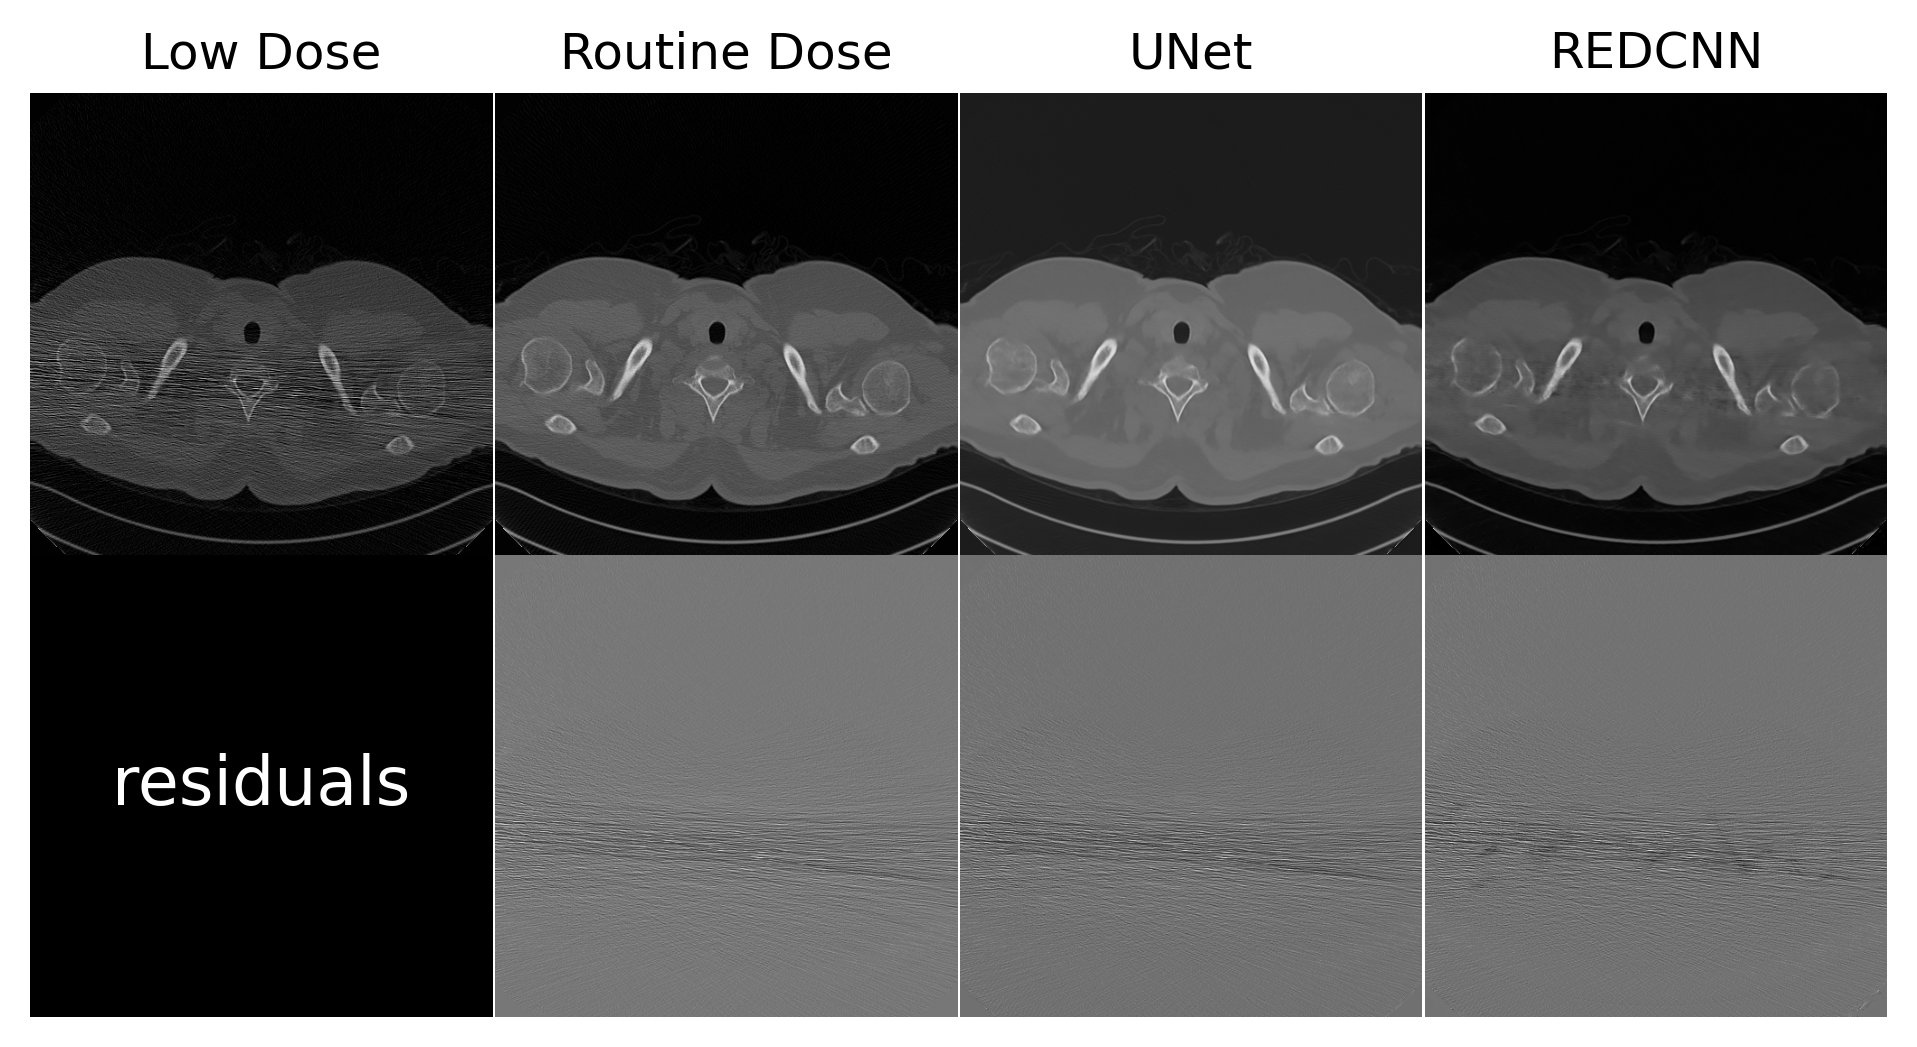

In [2]:
# Define the model
models = {'UNet': UNet.load_from_checkpoint('/projects01/didsr-aiml/jayse.weaver/denoising_models/MayoLDGC_Chest_UNet.ckpt'),
          'REDCNN': REDCNN.load_from_checkpoint('/projects01/didsr-aiml/jayse.weaver/denoising_models/MayoLDGC_Chest_REDCNN.ckpt')}

# Define the data module
data_module = MayoLDGCDataModule(data_dir='/projects01/didsr-aiml/common_data/Mayo_CT_LDGC', region='chest', shuffle=False)
data_module.setup('predict')
dataloader = data_module.predict_dataloader()

res = compare_denoising_outputs(models, dataloader)

## Head Models

I actually did make a Pytorch Lightning Module for our simulated head CT exams, though this data module might be too specific for my previous use case to be of use to you but you can check it out as  astarting point:

See <sim-head-dataset/make_heads_dataset.sh> which runs InsilicoICH to generate a low dose set of exams `head_ld.toml` and routine dose `head_rd.toml` using the same seed, the following data_module expects these two datasets to be in the same directory, but feel free to modify or make your own to fit your purpose

/projects01/didsr-aiml/jayse.weaver/denoising_models/.venv/lib/python3.12/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /projects01/didsr-aiml/jayse.weaver/denoising_models ...
You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/projects01/didsr-aiml/jayse.weaver/denoising_models/.venv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=5` in the `DataLoader` to imp

Predicting DataLoader 0: 100%|██████████| 6/6 [00:10<00:00,  0.58it/s]

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]



Predicting DataLoader 0: 100%|██████████| 6/6 [00:22<00:00,  0.27it/s] 


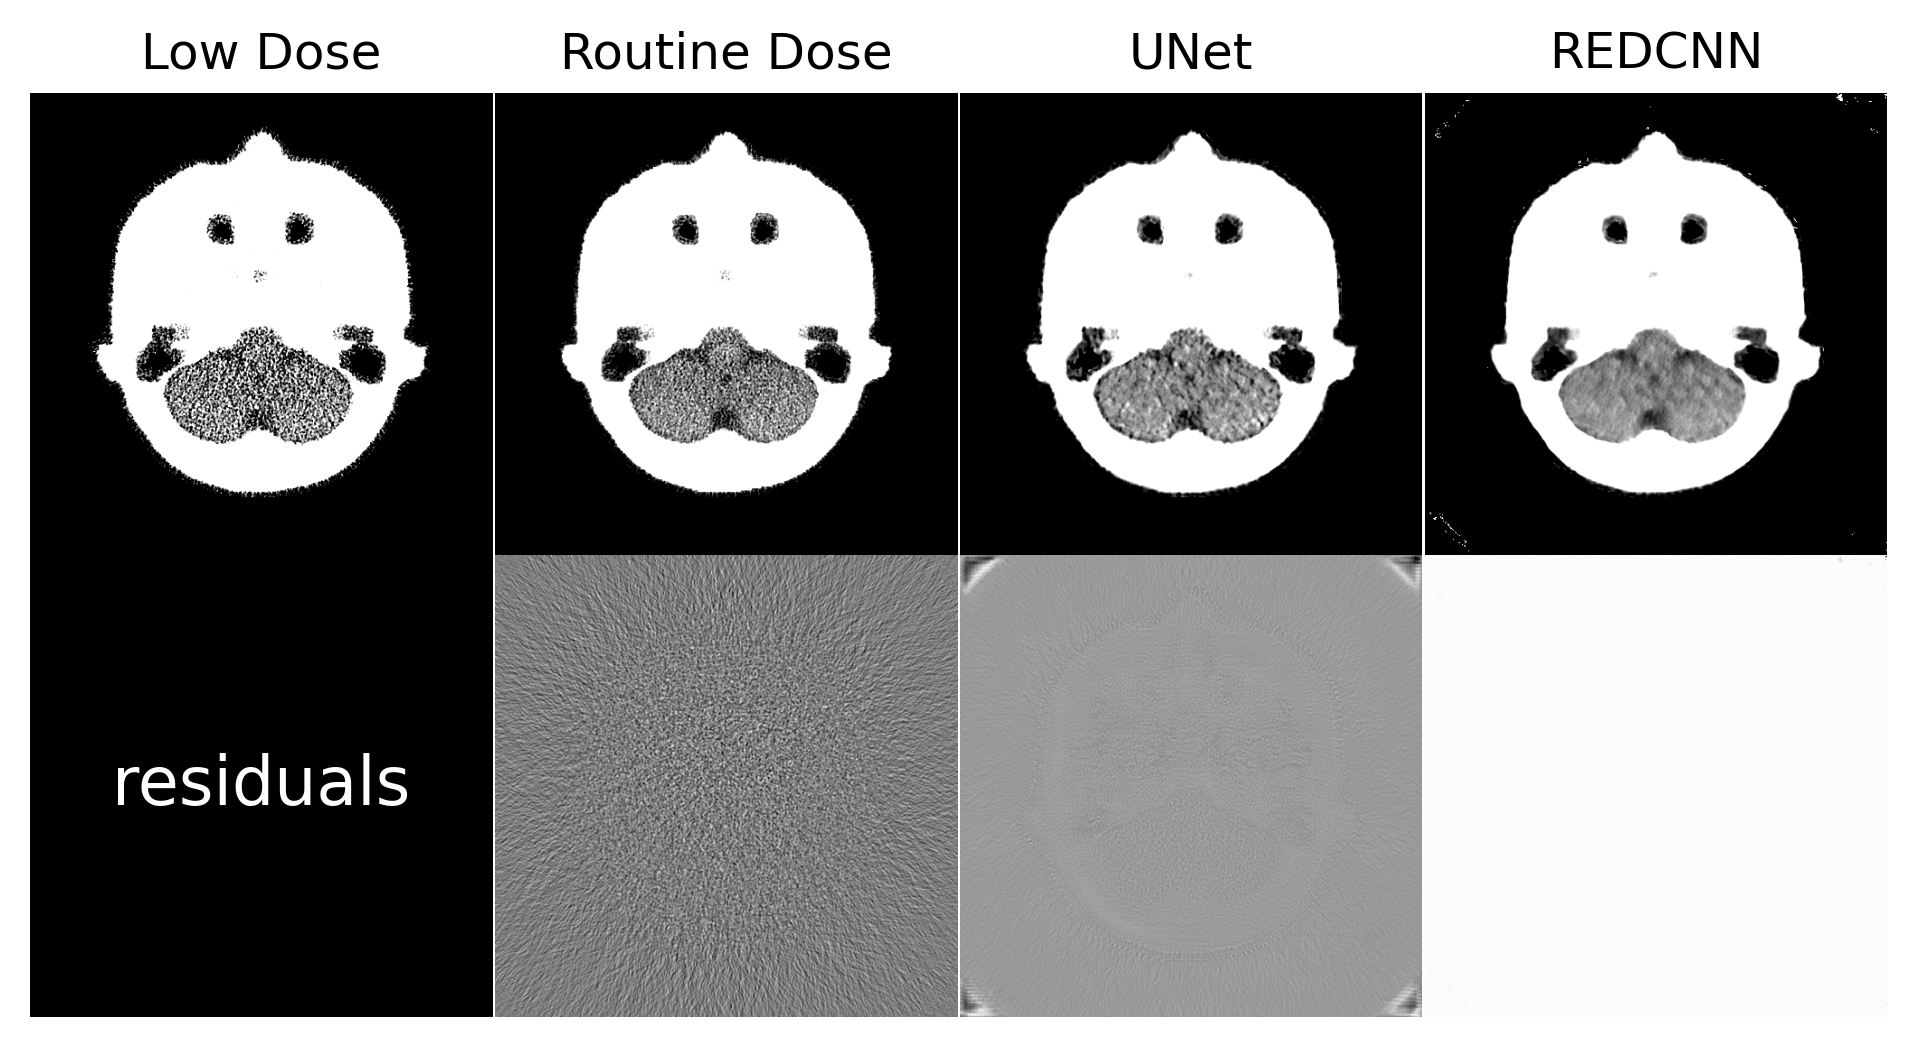

In [3]:
from data import HeadSimCTDataModule

# Define the data module
data_module = HeadSimCTDataModule(data_dir='/projects01/didsr-aiml/brandon.nelson/pedsilicoICH/head_experiment')
data_module.setup('predict')
synth_head_dataloader = data_module.predict_dataloader()
res = compare_denoising_outputs(models, synth_head_dataloader, wwwl=(80, 40))